In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
sb.set()

In [8]:
#import data file
netflix = pd.read_csv('netflix_titles.csv')
#see first few lines of data 
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Clean the dataset

In [12]:
#Create a copy of the dataset
netflix_clean = netflix.copy()

#Rename "show_id" to "ID"
netflix_clean.rename(columns = {'show_id': 'ID'}, inplace = True)

# Convert all Variable Names to UPPERCASE
netflix_clean.columns = netflix_clean.columns.str.upper()

# Print the Variable Information to check
netflix_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ID            8807 non-null   object
 1   TYPE          8807 non-null   object
 2   TITLE         8807 non-null   object
 3   DIRECTOR      6173 non-null   object
 4   CAST          7982 non-null   object
 5   COUNTRY       7976 non-null   object
 6   DATE_ADDED    8797 non-null   object
 7   RELEASE_YEAR  8807 non-null   int64 
 8   RATING        8803 non-null   object
 9   DURATION      8804 non-null   object
 10  LISTED_IN     8807 non-null   object
 11  DESCRIPTION   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [14]:
#Check if there are Titles with Duplicate IDs. If there is no duplicate IDs means that all the tiles are unique
dupid_data_clean = netflix_clean[netflix_clean.duplicated("ID", keep = False)]
print("Titles with Duplicate IDs :", len(dupid_data_clean))

Titles with Duplicate IDs : 0


Tackling the missing values

In [15]:
# Check how many missing values in data
netflix_clean.isnull().sum()

ID                 0
TYPE               0
TITLE              0
DIRECTOR        2634
CAST             825
COUNTRY          831
DATE_ADDED        10
RELEASE_YEAR       0
RATING             4
DURATION           3
LISTED_IN          0
DESCRIPTION        0
dtype: int64

Number of Genres: 514
LISTED_IN
Dramas, International Movies                                         1
Crime TV Shows, International TV Shows, Spanish-Language TV Shows    1
Docuseries                                                           1
Dramas, Thrillers                                                    1
Documentaries, Music & Musicals                                      1
Comedies, Romantic Movies                                            1
Action & Adventure, Comedies, International Movies                   1
TV Comedies                                                          1
International Movies, Thrillers                                      1
Thrillers                                                            1
International TV Shows, Korean TV Shows, Romantic TV Shows           1
Documentaries, Sports Movies                                         1
Action & Adventure, Sci-Fi & Fantasy                                 1
Documentaries                                

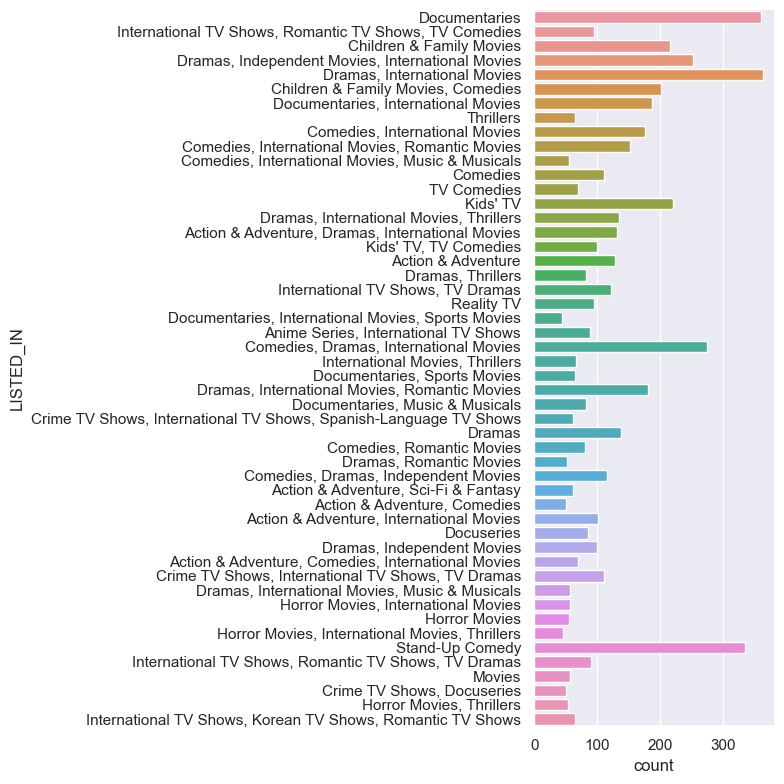

In [29]:
#Count how many categories there are in column "listed_in"
print("Number of Genres:", len(netflix_clean["LISTED_IN"].dropna().unique()))

#Different Genres of Titles
top_50 = netflix_clean["LISTED_IN"].dropna().value_counts().index[:50]
df_top_50 = netflix_clean[netflix_clean["LISTED_IN"].isin(top_50)]

print(top_50.dropna().value_counts())
sb.catplot(y = "LISTED_IN" , data = df_top_50, kind = "count", height = 8)
